# Smart Parking Demand — Use Case

**Authored by**: Shrikrishna Rai

**Duration**: 60 mins

**Level**: Intermediate

**Pre-requisite Skills**: Python, Pandas, Matplotlib, scikit-learn

### Scenario

As a city parking manager or researcher, you want to understand hourly parking demand across parking zones so you can optimise pricing, direct drivers to available bays, and plan future kerbside use. This notebook demonstrates how to ingest parking sensor and restriction data, merge them, and produce an hourly demand dataset suitable for EDA and simple predictive models.

### What this use case will teach you

- How to download and cache public transport and parking datasets from Melbourne open data.
- Clean and normalise heterogeneous datasets (API JSON and zipped CSVs).
- Merge live bay sensor data with parking restriction metadata.
- Compute hourly average occupancy and classify demand levels (Low / Medium / High).
- Build a simple baseline model and evaluate its performance using standard metrics.

### Background and Introduction

Urban parking demand varies by time of day, day of week, and local restrictions. Many cities deploy bay-level sensors that continuously report occupancy; combining this with sign-plate metadata (restrictions) and historical arrivals/departures enables interpretable demand analysis and simple forecasting.

This notebook focuses on Melbourne open-data sources and produces a cleaned dataset ready for exploratory visualisation and a baseline predictive model.

### Datasets used

- On-street Car Parking Sensor Data (2014) - historical parking events (zipped CSV).
- Parking bay arrivals and departures (2014) - event-level arrival/departure records (zipped CSV).
- On-street parking bay sensors - live bay status (API).
- Sign plates located in each parking zone - parking restriction metadata (API).

Follow the next cell to import required packages and run the ingestion steps.

### Imports

Required libraries for data, plotting, and modelling.

In [1]:
import matplotlib.pyplot as plt  
import pandas as pd  
import requests  
import zipfile 
from pathlib import Path  

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Local path where raw downloads are cached
RAW_DATA_DIR = Path("../data/raw")

# Remote datasets (zips) used in this notebook
CAR_PARKING_DATA_ZIP_URL = "https://opendatasoft-s3.s3.amazonaws.com/downloads/archive/t6hb-9uf2.zip"
PARKING_BAY_DATA_ZIP_URL = "https://opendatasoft-s3.s3.amazonaws.com/downloads/archive/mq3i-cbxd.zip"


def load_melbourne_api(dataset_slug, rows=5000):
    """Load a dataset from the Melbourne open data API and return a DataFrame.

    Args:
        dataset_slug: short dataset identifier used by the API
        rows: number of records to request (API paging)

    Returns:
        pandas.DataFrame built from the API 'records' -> 'fields'
    """
    url = "https://data.melbourne.vic.gov.au/api/records/1.0/search/"

    params = {"dataset": dataset_slug, "rows": rows}

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()
    records = data.get("records", [])

    # Convert list of record 'fields' into a DataFrame
    return pd.DataFrame([record["fields"] for record in records])


def download_file(url, destination):
    """Download a file (streamed) and save to the destination path.

    The function creates parent directories as needed and writes in chunks
    to avoid excessive memory usage for large files.
    """
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    with destination.open("wb") as output_file:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                output_file.write(chunk)

    return destination


def read_cached_zip_csv(zip_url, cache_name, nrows=None):
    """Download (if needed) a zip file and return the first CSV inside as a DataFrame.

    Args:
        zip_url: remote URL pointing to the zip archive
        cache_name: local filename to use for caching the downloaded zip
        nrows: optional limit for number of CSV rows to read (useful for development)
    """
    cache_path = RAW_DATA_DIR / cache_name

    if not cache_path.exists():
        # Download once and reuse the local cached file
        download_file(zip_url, cache_path)

    with zipfile.ZipFile(cache_path) as archive:
        csv_member = next(
            (name for name in archive.namelist() if name.lower().endswith(".csv")),
            None,
        )

        if csv_member is None:
            raise ValueError(f"No CSV file found inside {cache_path.name}")

        with archive.open(csv_member) as csv_file:
            return pd.read_csv(csv_file, nrows=nrows)

### Data ingestion

Download or load cached datasets used in this analysis.

In [2]:
# --- Load datasets (may take time on first run) ---
on_street_parking_bay_sensor_df = load_melbourne_api("on-street-parking-bay-sensors", rows=5000)

sign_plates_located_in_parking_bays_df = load_melbourne_api(
    "sign-plates-located-in-each-parking-zone",
    rows=5000,
)

on_street_car_parking_sensor_df = read_cached_zip_csv(
    CAR_PARKING_DATA_ZIP_URL,
    "On-street_Car_Parking_Sensor_Data_-_2014.zip",
    nrows=300000,
)

parking_bay_arrivals_and_departures_df = read_cached_zip_csv(
    PARKING_BAY_DATA_ZIP_URL,
    "Parking_bay_arrivals_and_departures_2014.zip",
    nrows=300000,
)

/tmp/ipykernel_12085/3820245346.py:99: DtypeWarning: Columns (0: StreetId, 1: BetweenStreet1 Id, 2: BetweenStreet2 Id) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(csv_file, nrows=nrows)


In [3]:
print("**on_street_car_parking_sensor_df**")
print(on_street_car_parking_sensor_df.head())
print(on_street_car_parking_sensor_df.columns)
on_street_car_parking_sensor_df.info()

**on_street_car_parking_sensor_df**
  DeviceId             ArrivalTime           DepartureTime DurationSeconds  \
0   10,032  07/01/2014 11:43:23 AM  07/01/2014 11:43:30 AM               7   
1   11,649  03/19/2014 10:09:38 AM  03/19/2014 10:11:22 AM             104   
2    9,126  06/12/2014 07:30:00 AM  06/12/2014 10:17:23 AM          10,043   
3   12,462  07/02/2014 07:30:11 AM  07/02/2014 07:34:11 AM             240   
4   14,588  07/16/2014 08:12:00 AM  07/16/2014 08:12:14 AM              14   

  StreetMarker                       Sign            Area StreetId  \
0        3273S      1P MTR M-F 9:30-19:30          County      894   
1        2206N  1/2P MTR M-SAT 7:30-19:30        McKillop      911   
2       11921W      2P MTR M-F 7:30-18:30  East Melbourne      511   
3        2418N       1/4P M-SAT 7:30-9:30            RACV      123   
4       13749W  2P TKT A M-SAT 7:30-18:30       Docklands    1,398   

          StreetName   BetweenStreet1      BetweenStreet2  Side Of Street 

In [4]:
print("**on_street_parking_bay_sensor_df**")
print(on_street_parking_bay_sensor_df.head())
print(on_street_parking_bay_sensor_df.columns)
on_street_parking_bay_sensor_df.info()

**on_street_parking_bay_sensor_df**
            status_timestamp  zone_number                lastupdated  \
0  2025-04-14T03:01:40+00:00       7218.0  2025-05-08T05:44:34+00:00   
1  2024-03-06T20:13:57+00:00          NaN  2025-05-08T05:44:34+00:00   
2  2025-04-13T20:29:07+00:00       7219.0  2025-05-08T05:44:34+00:00   
3  2025-04-14T02:56:13+00:00       7219.0  2025-05-08T05:44:34+00:00   
4  2024-06-16T21:36:41+00:00       7081.0  2025-04-08T23:44:37+00:00   

   kerbsideid status_description                                   location  
0       57940         Unoccupied   [-37.82027020009988, 144.95458322910955]  
1       23372            Present  [-37.818697732486505, 144.95573756544826]  
2       69943            Present   [-37.82250487011976, 144.95216400545675]  
3       69946            Present   [-37.82253375737386, 144.95206800770742]  
4        8396         Unoccupied   [-37.80684173874762, 144.97325296739342]  
Index(['status_timestamp', 'zone_number', 'lastupdated', 'kerbs

In [5]:
print("**parking_bay_arrivals_and_departures_df**")
print(parking_bay_arrivals_and_departures_df.head())
print(parking_bay_arrivals_and_departures_df.columns)
parking_bay_arrivals_and_departures_df.info()

**parking_bay_arrivals_and_departures_df**
  ParkingEventId DeviceId                   ArrivalTime  \
0          3,123   11,710  04/02/2014 10:56:29 AM +0000   
1          3,124   11,710  04/02/2014 11:07:23 AM +0000   
2          3,125   11,710  04/02/2014 12:09:59 PM +0000   
3          3,126   11,710  04/02/2014 12:39:30 PM +0000   
4          3,129   11,710  04/02/2014 01:08:46 PM +0000   

                  DepartureTime DurationSeconds StreetMarker  SignPlateId  \
0  04/02/2014 11:06:08 AM +0000             600        6588N            6   
1  04/02/2014 11:38:48 AM +0000           1,860        6588N            6   
2  04/02/2014 12:34:30 PM +0000           1,500        6588N            6   
3  04/02/2014 12:58:07 PM +0000           1,140        6588N            6   
4  04/02/2014 01:14:46 PM +0000             360        6588N            6   

                      Sign  Area         AreaName  ...       StreetName  \
0  1P MTR M-SAT 7:30-19:30    12  Victoria Market  ...  FRANKLIN

In [6]:
print("**sign_plates_located_in_parking_bays_df**")
print(sign_plates_located_in_parking_bays_df.head())
print(sign_plates_located_in_parking_bays_df.columns)
sign_plates_located_in_parking_bays_df.info()

**sign_plates_located_in_parking_bays_df**
  restriction_display  parkingzone time_restrictions_start restriction_days  \
0                  2P         7003                07:30:00          Mon-Fri   
1                  1P         7009                07:30:00              Sat   
2                  1P         7056                07:30:00              Sat   
3                  2P         7066                07:30:00          Mon-Fri   
4                  2P         7062                07:30:00              Sat   

  time_restrictions_finish  
0                 18:30:00  
1                 12:30:00  
2                 12:30:00  
3                 18:30:00  
4                 12:30:00  
Index(['restriction_display', 'parkingzone', 'time_restrictions_start',
       'restriction_days', 'time_restrictions_finish'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2033 entries, 0 to 2032
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------  

In [7]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

on_street_car_parking_sensor_df = clean_column_names(on_street_car_parking_sensor_df)
on_street_parking_bay_sensor_df = clean_column_names(on_street_parking_bay_sensor_df)
parking_bay_arrivals_and_departures_df = clean_column_names(parking_bay_arrivals_and_departures_df)
sign_plates_located_in_parking_bays_df = clean_column_names(sign_plates_located_in_parking_bays_df)

In [8]:
print("on_street_car_parking_sensor_df columns:")
print(on_street_car_parking_sensor_df.columns.tolist())

print("\non_street_parking_bay_sensor_df columns:")
print(on_street_parking_bay_sensor_df.columns.tolist())

print("\nparking_bay_arrivals_and_departures_df columns:")
print(parking_bay_arrivals_and_departures_df.columns.tolist())

print("\nsign_plates_located_in_parking_bays_df columns:")
print(sign_plates_located_in_parking_bays_df.columns.tolist())

on_street_car_parking_sensor_df columns:
['deviceid', 'arrivaltime', 'departuretime', 'durationseconds', 'streetmarker', 'sign', 'area', 'streetid', 'streetname', 'betweenstreet1', 'betweenstreet2', 'side_of_street', 'in_violation', 'vehicle_present']

on_street_parking_bay_sensor_df columns:
['status_timestamp', 'zone_number', 'lastupdated', 'kerbsideid', 'status_description', 'location']

parking_bay_arrivals_and_departures_df columns:
['parkingeventid', 'deviceid', 'arrivaltime', 'departuretime', 'durationseconds', 'streetmarker', 'signplateid', 'sign', 'area', 'areaname', 'streetid', 'streetname', 'betweenstreet1_id', 'betweenstreet1_description', 'betweenstreet2_id', 'betweenstreet2_description', 'sideofstreet', 'sidecode', 'sidename', 'bayid', 'inviolation']

sign_plates_located_in_parking_bays_df columns:
['restriction_display', 'parkingzone', 'time_restrictions_start', 'restriction_days', 'time_restrictions_finish']


In [9]:
on_street_car_parking_sensor_df = on_street_car_parking_sensor_df.drop_duplicates()
on_street_parking_bay_sensor_df["location"] = (
    on_street_parking_bay_sensor_df["location"].apply(
        lambda value: tuple(value) if isinstance(value, list) else value
    )
)
on_street_parking_bay_sensor_df = on_street_parking_bay_sensor_df.drop_duplicates()
parking_bay_arrivals_and_departures_df = parking_bay_arrivals_and_departures_df.drop_duplicates()
sign_plates_located_in_parking_bays_df = sign_plates_located_in_parking_bays_df.drop_duplicates()

In [10]:
# For 2014 sensor data
on_street_car_parking_sensor_df["deviceid"] = (
    on_street_car_parking_sensor_df["deviceid"].astype(str).str.replace(",", "", regex=False)
)
on_street_car_parking_sensor_df["streetid"] = (
    on_street_car_parking_sensor_df["streetid"].astype(str).str.replace(",", "", regex=False)
)
on_street_car_parking_sensor_df["durationseconds"] = (
    on_street_car_parking_sensor_df["durationseconds"].astype(str).str.replace(",", "", regex=False)
)

# For arrivals/departures data
parking_bay_arrivals_and_departures_df["parkingeventid"] = (
    parking_bay_arrivals_and_departures_df["parkingeventid"].astype(str).str.replace(",", "", regex=False)
)
parking_bay_arrivals_and_departures_df["deviceid"] = (
    parking_bay_arrivals_and_departures_df["deviceid"].astype(str).str.replace(",", "", regex=False)
)
parking_bay_arrivals_and_departures_df["durationseconds"] = (
    parking_bay_arrivals_and_departures_df["durationseconds"].astype(str).str.replace(",", "", regex=False)
)
parking_bay_arrivals_and_departures_df["bayid"] = (
    parking_bay_arrivals_and_departures_df["bayid"].astype(str).str.replace(",", "", regex=False)
)

In [11]:
on_street_car_parking_sensor_df["deviceid"] = pd.to_numeric(on_street_car_parking_sensor_df["deviceid"], errors="coerce")
on_street_car_parking_sensor_df["streetid"] = pd.to_numeric(on_street_car_parking_sensor_df["streetid"], errors="coerce")
on_street_car_parking_sensor_df["durationseconds"] = pd.to_numeric(on_street_car_parking_sensor_df["durationseconds"], errors="coerce")

parking_bay_arrivals_and_departures_df["parkingeventid"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["parkingeventid"], errors="coerce")
parking_bay_arrivals_and_departures_df["deviceid"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["deviceid"], errors="coerce")
parking_bay_arrivals_and_departures_df["durationseconds"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["durationseconds"], errors="coerce")
parking_bay_arrivals_and_departures_df["bayid"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["bayid"], errors="coerce")

In [12]:
on_street_car_parking_sensor_df["arrivaltime"] = pd.to_datetime(
    on_street_car_parking_sensor_df["arrivaltime"],
    errors="coerce"
)

on_street_car_parking_sensor_df["departuretime"] = pd.to_datetime(
    on_street_car_parking_sensor_df["departuretime"],
    errors="coerce"
)

on_street_parking_bay_sensor_df["lastupdated"] = pd.to_datetime(
    on_street_parking_bay_sensor_df["lastupdated"],
    errors="coerce",
    utc=True
)

on_street_parking_bay_sensor_df["status_timestamp"] = pd.to_datetime(
    on_street_parking_bay_sensor_df["status_timestamp"],
    errors="coerce",
    utc=True
)

parking_bay_arrivals_and_departures_df["arrivaltime"] = pd.to_datetime(
    parking_bay_arrivals_and_departures_df["arrivaltime"],
    errors="coerce"
)

parking_bay_arrivals_and_departures_df["departuretime"] = pd.to_datetime(
    parking_bay_arrivals_and_departures_df["departuretime"],
    errors="coerce"
)

In [13]:
on_street_car_parking_sensor_df = on_street_car_parking_sensor_df.dropna(
    subset=["deviceid", "arrivaltime", "departuretime"]
)

on_street_parking_bay_sensor_df = on_street_parking_bay_sensor_df.dropna(
    subset=["status_timestamp", "status_description", "kerbsideid"]
)

parking_bay_arrivals_and_departures_df = parking_bay_arrivals_and_departures_df.dropna(
    subset=["deviceid", "arrivaltime", "departuretime", "bayid"]
)

sign_plates_located_in_parking_bays_df = sign_plates_located_in_parking_bays_df.dropna(
    subset=["parkingzone"]
)

In [14]:
# 2014 sensor data
on_street_car_parking_sensor_df["arrival_hour"] = on_street_car_parking_sensor_df["arrivaltime"].dt.hour
on_street_car_parking_sensor_df["arrival_day"] = on_street_car_parking_sensor_df["arrivaltime"].dt.day_name()
on_street_car_parking_sensor_df["arrival_month"] = on_street_car_parking_sensor_df["arrivaltime"].dt.month
on_street_car_parking_sensor_df["is_weekend"] = on_street_car_parking_sensor_df["arrivaltime"].dt.dayofweek >= 5

# Live bay sensor data
on_street_parking_bay_sensor_df["status_hour"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.hour
on_street_parking_bay_sensor_df["status_day"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.day_name()
on_street_parking_bay_sensor_df["status_month"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.month
on_street_parking_bay_sensor_df["is_weekend"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.dayofweek >= 5

# Arrivals/departures data
parking_bay_arrivals_and_departures_df["arrival_hour"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.hour
parking_bay_arrivals_and_departures_df["arrival_day"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.day_name()
parking_bay_arrivals_and_departures_df["arrival_month"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.month
parking_bay_arrivals_and_departures_df["is_weekend"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.dayofweek >= 5

In [15]:
# Keep timestamps timezone-naive so they are easier to read and export
on_street_parking_bay_sensor_df["lastupdated"] = (
    on_street_parking_bay_sensor_df["lastupdated"].dt.tz_convert(None)
)

on_street_parking_bay_sensor_df["status_timestamp"] = (
    on_street_parking_bay_sensor_df["status_timestamp"].dt.tz_convert(None)
)

In [16]:
on_street_parking_bay_sensor_df["occupied"] = on_street_parking_bay_sensor_df["status_description"].apply(
    lambda x: 1 if x == "Present" else 0
)

on_street_parking_bay_sensor_df["occupied"].value_counts()

occupied
1    1669
0    1640
Name: count, dtype: int64

In [17]:
sign_plates_located_in_parking_bays_df = sign_plates_located_in_parking_bays_df.rename(
    columns={"parkingzone": "zone_number"}
)

sign_plates_located_in_parking_bays_df.head()

,restriction_display,zone_number,time_restrictions_start,restriction_days,time_restrictions_finish
0,2P,7003,07:30:00,Mon-Fri,18:30:00
1,1P,7009,07:30:00,Sat,12:30:00
2,1P,7056,07:30:00,Sat,12:30:00
3,2P,7066,07:30:00,Mon-Fri,18:30:00
4,2P,7062,07:30:00,Sat,12:30:00


In [18]:
merged_bay_df = on_street_parking_bay_sensor_df.merge(
    sign_plates_located_in_parking_bays_df,
    on="zone_number",
    how="left"
)

print("Merged shape:", merged_bay_df.shape)
display(merged_bay_df.head())

Merged shape: (7989, 15)


,status_timestamp,zone_number,lastupdated,kerbsideid,status_description,location,status_hour,status_day,status_month,is_weekend,occupied,restriction_display,time_restrictions_start,restriction_days,time_restrictions_finish
0,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,19:00:00,Mon-Fri,22:00:00
1,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,07:00:00,Sat-Sun,22:00:00
2,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,09:00:00,Mon-Fri,16:00:00
3,2024-03-06 20:13:57,NaN,2025-05-08 05:44:34,23372,Present,"(-37.818697732486505, 144.95573756544826)",20,Wednesday,3,False,1,NaN,NaN,NaN,NaN
4,2025-04-13 20:29:07,7219.0,2025-05-08 05:44:34,69943,Present,"(-37.82250487011976, 144.95216400545675)",20,Sunday,4,True,1,LZ30,07:00:00,Mon-Fri,16:00:00


In [19]:
merged_bay_df.info()
print("\nMissing values after merge:")
print(merged_bay_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7989 entries, 0 to 7988
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   status_timestamp          7989 non-null   datetime64[us]
 1   zone_number               7766 non-null   float64       
 2   lastupdated               7989 non-null   datetime64[us]
 3   kerbsideid                7989 non-null   int64         
 4   status_description        7989 non-null   str           
 5   location                  7989 non-null   object        
 6   status_hour               7989 non-null   int32         
 7   status_day                7989 non-null   str           
 8   status_month              7989 non-null   int32         
 9   is_weekend                7989 non-null   bool          
 10  occupied                  7989 non-null   int64         
 11  restriction_display       7721 non-null   str           
 12  time_restrictions_start   7721 

In [20]:
# We need zone_number for grouping, so remove rows where it is missing
merged_bay_df = merged_bay_df.dropna(subset=["zone_number"])

# Fill restriction details so downstream analysis has readable values
merged_bay_df["restriction_days"] = merged_bay_df["restriction_days"].fillna("Unknown")
merged_bay_df["restriction_display"] = merged_bay_df["restriction_display"].fillna("Unknown")
merged_bay_df["time_restrictions_start"] = merged_bay_df["time_restrictions_start"].fillna("Unknown")
merged_bay_df["time_restrictions_finish"] = merged_bay_df["time_restrictions_finish"].fillna("Unknown")

Data merge: dropped rows missing `zone_number`; filled missing restriction fields with 'Unknown'.

In [21]:
# Group occupancy by zone, day, hour, and weekend status
demand_df = (
    merged_bay_df.groupby(
        ["zone_number", "status_day", "status_hour", "is_weekend"],
        as_index=False
    )["occupied"].mean()
)

demand_df = demand_df.rename(columns={"occupied": "average_occupancy"})

display(demand_df.head())
print("Demand dataset shape:", demand_df.shape)

,zone_number,status_day,status_hour,is_weekend,average_occupancy
0,7010.0,Friday,1,False,0.0
1,7010.0,Thursday,21,False,1.0
2,7010.0,Thursday,22,False,1.0
3,7010.0,Thursday,23,False,1.0
4,7010.0,Wednesday,9,False,0.0


Demand dataset shape: (1544, 5)


In [22]:
def demand_level(value):
    if value < 0.33:
        return "Low"
    elif value < 0.66:
        return "Medium"
    else:
        return "High"

demand_df["demand_level"] = demand_df["average_occupancy"].apply(demand_level)

demand_df.head()

,zone_number,status_day,status_hour,is_weekend,average_occupancy,demand_level
0,7010.0,Friday,1,False,0.0,Low
1,7010.0,Thursday,21,False,1.0,High
2,7010.0,Thursday,22,False,1.0,High
3,7010.0,Thursday,23,False,1.0,High
4,7010.0,Wednesday,9,False,0.0,Low


In [23]:
print("Statistical summary of demand dataset:")
print(demand_df.describe())

Statistical summary of demand dataset:
       zone_number  status_hour  average_occupancy
count  1544.000000  1544.000000        1544.000000
mean   7463.501295     8.638601           0.480352
std     252.256803     7.086099           0.456683
min    7010.000000     0.000000           0.000000
25%    7237.000000     4.000000           0.000000
50%    7451.500000     6.000000           0.500000
75%    7642.250000    12.000000           1.000000
max    7995.000000    23.000000           1.000000


In [24]:
print("Missing values in cleaned demand_df:")
print(demand_df.isnull().sum())

Missing values in cleaned demand_df:
zone_number          0
status_day           0
status_hour          0
is_weekend           0
average_occupancy    0
demand_level         0
dtype: int64


In [25]:
# Save processed files
merged_bay_df.to_csv("../data/processed/merged_bay_sensor_data.csv", index=False)
demand_df.to_csv("../data/processed/cleaned_demand_data.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


## Exploratory Data Analysis

Quick EDA: hourly, daily and zone patterns.

In [26]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Merged dataset preview:")
display(merged_bay_df.head())
print("\nMerged dataset info:")
print(merged_bay_df.info())
print("\nMissing values in merged_bay_df:")
print(merged_bay_df.isnull().sum())

print("\nDemand dataset preview:")
display(demand_df.head())
print("\nDemand dataset info:")
print(demand_df.info())
print("\nMissing values in demand_df:")
print(demand_df.isnull().sum())

Merged dataset preview:


,status_timestamp,zone_number,lastupdated,kerbsideid,status_description,location,status_hour,status_day,status_month,is_weekend,occupied,restriction_display,time_restrictions_start,restriction_days,time_restrictions_finish
0,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,19:00:00,Mon-Fri,22:00:00
1,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,07:00:00,Sat-Sun,22:00:00
2,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,09:00:00,Mon-Fri,16:00:00
4,2025-04-13 20:29:07,7219.0,2025-05-08 05:44:34,69943,Present,"(-37.82250487011976, 144.95216400545675)",20,Sunday,4,True,1,LZ30,07:00:00,Mon-Fri,16:00:00
5,2025-04-13 20:29:07,7219.0,2025-05-08 05:44:34,69943,Present,"(-37.82250487011976, 144.95216400545675)",20,Sunday,4,True,1,MP2P,16:00:00,Mon-Fri,19:00:00



Merged dataset info:
<class 'pandas.DataFrame'>
Index: 7766 entries, 0 to 7988
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   status_timestamp          7766 non-null   datetime64[us]
 1   zone_number               7766 non-null   float64       
 2   lastupdated               7766 non-null   datetime64[us]
 3   kerbsideid                7766 non-null   int64         
 4   status_description        7766 non-null   str           
 5   location                  7766 non-null   object        
 6   status_hour               7766 non-null   int32         
 7   status_day                7766 non-null   str           
 8   status_month              7766 non-null   int32         
 9   is_weekend                7766 non-null   bool          
 10  occupied                  7766 non-null   int64         
 11  restriction_display       7766 non-null   str           
 12  time_restricti

,zone_number,status_day,status_hour,is_weekend,average_occupancy,demand_level
0,7010.0,Friday,1,False,0.0,Low
1,7010.0,Thursday,21,False,1.0,High
2,7010.0,Thursday,22,False,1.0,High
3,7010.0,Thursday,23,False,1.0,High
4,7010.0,Wednesday,9,False,0.0,Low



Demand dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1544 entries, 0 to 1543
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   zone_number        1544 non-null   float64
 1   status_day         1544 non-null   str    
 2   status_hour        1544 non-null   int32  
 3   is_weekend         1544 non-null   bool   
 4   average_occupancy  1544 non-null   float64
 5   demand_level       1544 non-null   str    
dtypes: bool(1), float64(2), int32(1), str(2)
memory usage: 55.9 KB
None

Missing values in demand_df:
zone_number          0
status_day           0
status_hour          0
is_weekend           0
average_occupancy    0
demand_level         0
dtype: int64


### 1. Average Parking Demand by Hour

,status_hour,average_occupancy
0,0,0.663661
1,1,0.613698
2,2,0.532211
3,3,0.503505
4,4,0.515620
5,5,0.480598
6,6,0.439457
7,7,0.445578
8,8,0.358013
9,9,0.361360


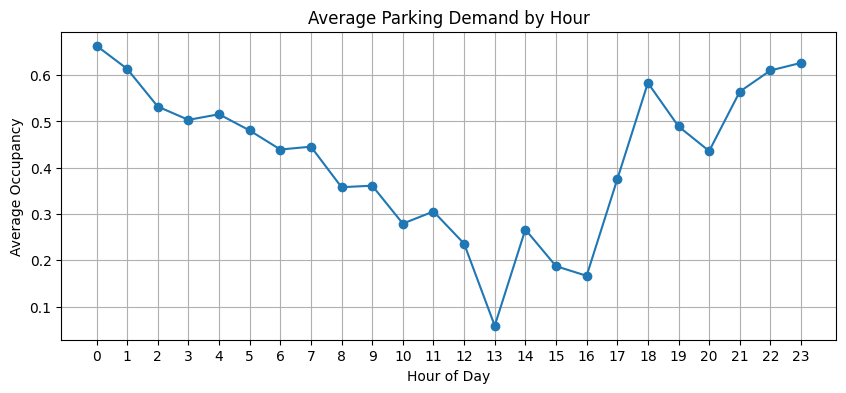

In [27]:
hourly_demand = demand_df.groupby("status_hour", as_index=False)["average_occupancy"].mean()
display(hourly_demand)

plt.figure(figsize=(10, 4))
plt.plot(hourly_demand["status_hour"], hourly_demand["average_occupancy"], marker="o")
plt.title("Average Parking Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### 2. Average Parking Demand by Day of the Week

,status_day,average_occupancy
1,Monday,0.529370
5,Tuesday,0.487656
6,Wednesday,0.540515
4,Thursday,0.405518
0,Friday,0.502857
2,Saturday,0.345890
3,Sunday,0.428523


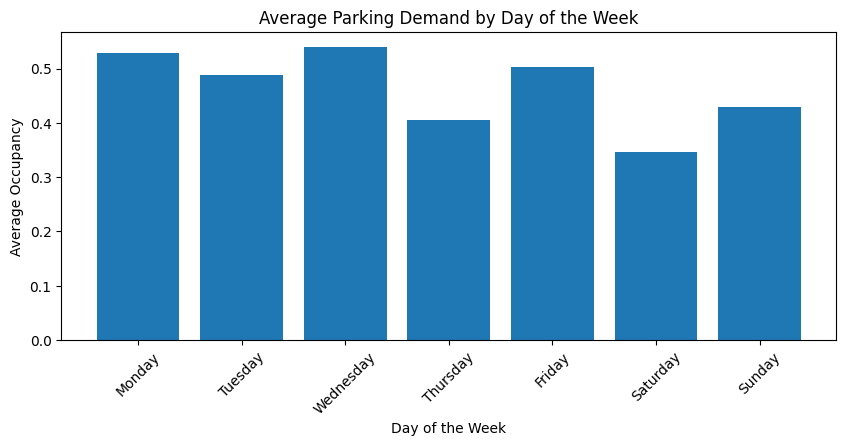

In [28]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_demand = demand_df.groupby("status_day", as_index=False)["average_occupancy"].mean()
daily_demand["status_day"] = pd.Categorical(daily_demand["status_day"], categories=day_order, ordered=True)
daily_demand = daily_demand.sort_values("status_day")
display(daily_demand)

plt.figure(figsize=(10, 4))
plt.bar(daily_demand["status_day"], daily_demand["average_occupancy"])
plt.title("Average Parking Demand by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

### 3. Demand Level Distribution

demand_level
Low       691
High      670
Medium    183
Name: count, dtype: int64


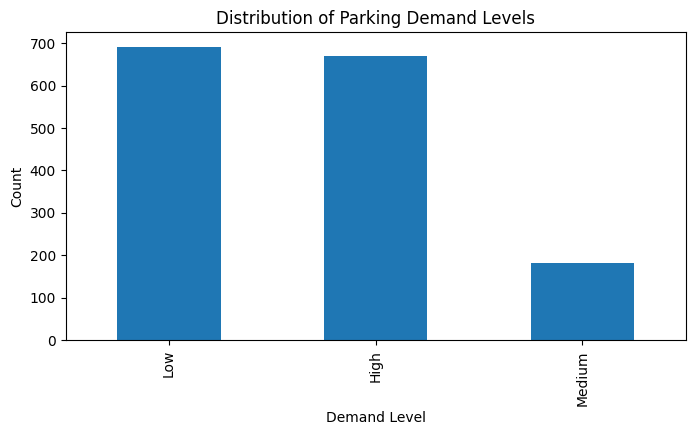

In [29]:
print(demand_df["demand_level"].value_counts())

plt.figure(figsize=(8, 4))
demand_df["demand_level"].value_counts().plot(kind="bar")
plt.title("Distribution of Parking Demand Levels")
plt.xlabel("Demand Level")
plt.ylabel("Count")
plt.show()

### 4. Zone-Based Parking Demand

,zone_number,average_occupancy,observation_count
2,7014.0,1.0,8
295,7740.0,1.0,10
32,7191.0,1.0,4
24,7182.0,1.0,3
27,7185.0,1.0,3
51,7223.0,1.0,8
21,7170.0,1.0,4
33,7193.0,1.0,5
280,7706.0,1.0,4
40,7205.0,1.0,1


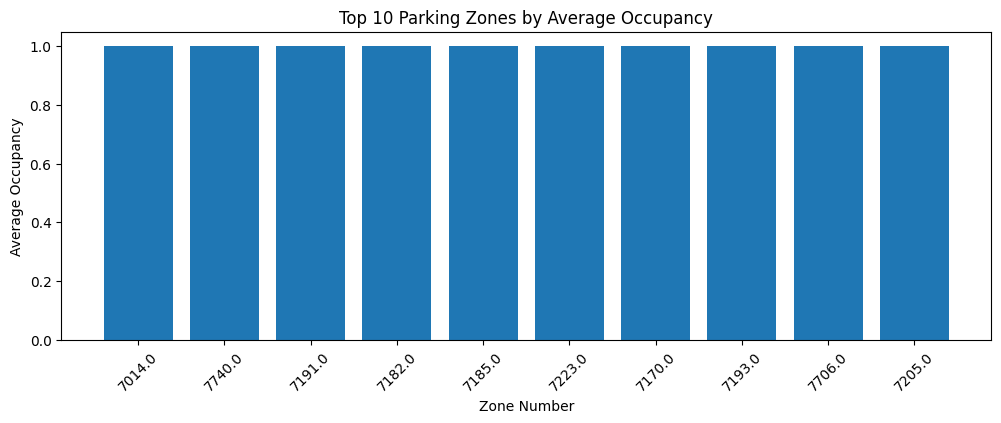

In [30]:
zone_summary = (
    merged_bay_df.groupby("zone_number")
    .agg(average_occupancy=("occupied", "mean"), observation_count=("occupied", "count"))
    .reset_index()
    .sort_values("average_occupancy", ascending=False)
)

display(zone_summary.head(10))

plt.figure(figsize=(12, 4))
plt.bar(zone_summary.head(10)["zone_number"].astype(str), zone_summary.head(10)["average_occupancy"])
plt.title("Top 10 Parking Zones by Average Occupancy")
plt.xlabel("Zone Number")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

### 5. Parking Restrictions and Weekend Patterns

,restriction_display,occupied
6,HP,1.000000
7,LZ15,0.666667
0,1P,0.582697
3,DP2P,0.545455
10,MP2P,0.511703
1,2P,0.489485
8,LZ30,0.472789
13,SP,0.454545
14,Unknown,0.444444
5,FP2P,0.375000


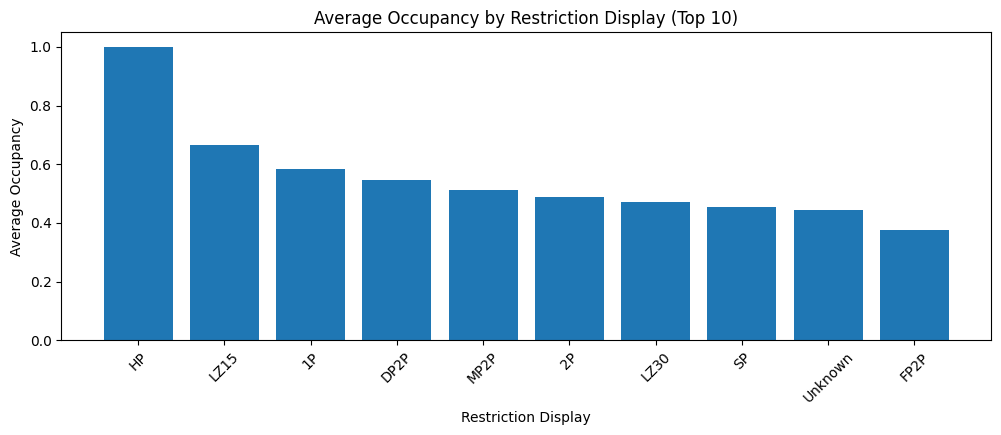

,is_weekend,occupied
0,False,0.508621
1,True,0.418118


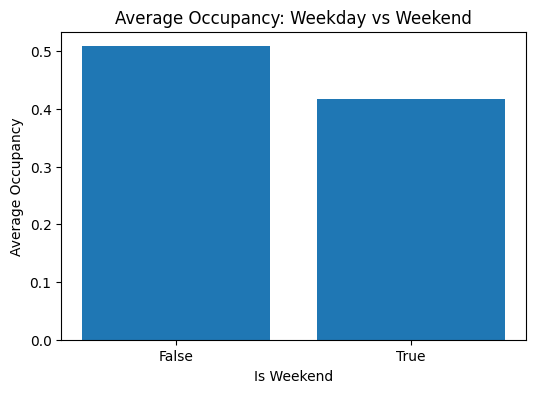

,status_hour,is_weekend,average_occupancy
0,0,False,0.658237
1,0,True,0.700000
2,1,False,0.587973
3,1,True,0.772727
4,2,False,0.546691


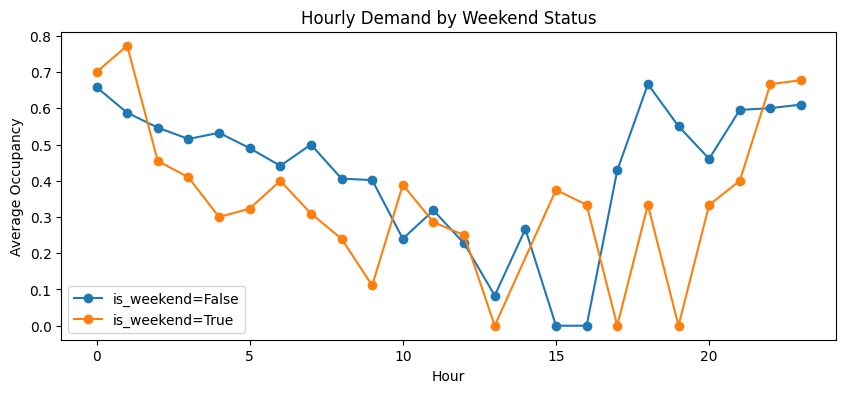

In [31]:
restriction_demand = (
    merged_bay_df.groupby("restriction_display", as_index=False)["occupied"]
    .mean()
    .sort_values("occupied", ascending=False)
)
weekend_comparison = merged_bay_df.groupby("is_weekend", as_index=False)["occupied"].mean()
hour_weekend_demand = demand_df.groupby(["status_hour", "is_weekend"], as_index=False)["average_occupancy"].mean()

display(restriction_demand.head(10))
plt.figure(figsize=(12, 4))
plt.bar(restriction_demand.head(10)["restriction_display"], restriction_demand.head(10)["occupied"])
plt.title("Average Occupancy by Restriction Display (Top 10)")
plt.xlabel("Restriction Display")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

display(weekend_comparison)
plt.figure(figsize=(6, 4))
plt.bar(weekend_comparison["is_weekend"].astype(str), weekend_comparison["occupied"])
plt.title("Average Occupancy: Weekday vs Weekend")
plt.xlabel("Is Weekend")
plt.ylabel("Average Occupancy")
plt.show()

display(hour_weekend_demand.head())
plt.figure(figsize=(10, 4))
for weekend_value in hour_weekend_demand["is_weekend"].unique():
    subset = hour_weekend_demand[hour_weekend_demand["is_weekend"] == weekend_value]
    plt.plot(subset["status_hour"], subset["average_occupancy"], marker="o", label=f"is_weekend={weekend_value}")
plt.legend()
plt.title("Hourly Demand by Weekend Status")
plt.xlabel("Hour")
plt.ylabel("Average Occupancy")
plt.show()

### 6. Statistical Summary

In [32]:
print("Statistical summary of demand dataset:")
print(demand_df.describe())
print("\nCorrelation summary:")
print(demand_df[["zone_number", "status_hour", "is_weekend", "average_occupancy"]].corr(numeric_only=True))

Statistical summary of demand dataset:
       zone_number  status_hour  average_occupancy
count  1544.000000  1544.000000        1544.000000
mean   7463.501295     8.638601           0.480352
std     252.256803     7.086099           0.456683
min    7010.000000     0.000000           0.000000
25%    7237.000000     4.000000           0.000000
50%    7451.500000     6.000000           0.500000
75%    7642.250000    12.000000           1.000000
max    7995.000000    23.000000           1.000000

Correlation summary:
                   zone_number  status_hour  is_weekend  average_occupancy
zone_number           1.000000    -0.062919   -0.040855          -0.083085
status_hour          -0.062919     1.000000    0.118103          -0.005655
is_weekend           -0.040855     0.118103    1.000000          -0.070911
average_occupancy    -0.083085    -0.005655   -0.070911           1.000000


## Machine Learning Model Development

The target variable is `demand_level`, which classifies parking demand as low, medium, or high. This section trains baseline and tree-based models using the engineered temporal and spatial features.

In [33]:
X = demand_df[["zone_number", "status_hour", "status_day", "is_weekend"]]
y = demand_df["demand_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Feature sample:")
display(X.head())
print("\nTarget sample:")
display(y.head())
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Feature sample:


,zone_number,status_hour,status_day,is_weekend
0,7010.0,1,Friday,False
1,7010.0,21,Thursday,False
2,7010.0,22,Thursday,False
3,7010.0,23,Thursday,False
4,7010.0,9,Wednesday,False



Target sample:


0     Low
1    High
2    High
3    High
4     Low
Name: demand_level, dtype: str


Training set size: (1235, 4)
Testing set size: (309, 4)


### 1. Feature Setup and Train-Test Split

In [34]:
numeric_features = ["zone_number", "status_hour"]
categorical_features = ["status_day", "is_weekend"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

### 2. Logistic Regression Baseline

Logistic Regression classification report:
              precision    recall  f1-score   support

        High       0.47      0.32      0.38       134
         Low       0.63      0.36      0.46       138
      Medium       0.20      0.76      0.32        37

    accuracy                           0.39       309
   macro avg       0.43      0.48      0.39       309
weighted avg       0.51      0.39      0.41       309



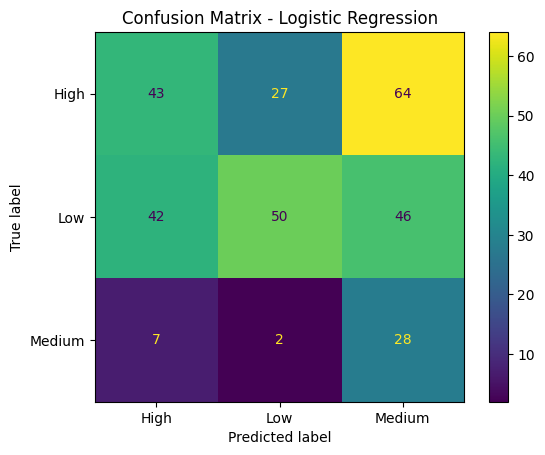

In [35]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000, class_weight="balanced")),
])
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression classification report:")
print(classification_report(y_test, y_pred_logistic))

cm_logistic = confusion_matrix(y_test, y_pred_logistic, labels=logistic_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=logistic_model.classes_)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### 3. Random Forest Model

Random Forest classification report:
              precision    recall  f1-score   support

        High       0.62      0.60      0.61       134
         Low       0.61      0.59      0.60       138
      Medium       0.36      0.43      0.40        37

    accuracy                           0.58       309
   macro avg       0.53      0.54      0.54       309
weighted avg       0.59      0.58      0.58       309



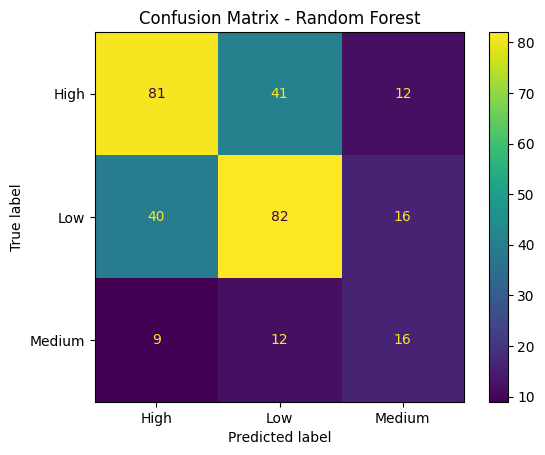

In [36]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
    )),
])
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=random_forest_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### 4. Model Comparison and Cross-Validation

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Logistic Regression,0.3916,0.4800,0.3871
1,Random Forest,0.5793,0.5437,0.5365


<Figure size 900x500 with 0 Axes>

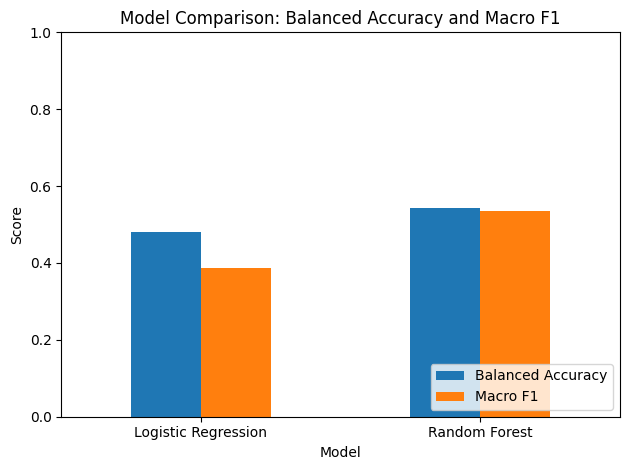

,Metric,Mean,Std
0,Accuracy,0.5168,0.0089
1,Balanced Accuracy,0.4560,0.0137
2,Macro F1,0.4527,0.0122


In [37]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_logistic), accuracy_score(y_test, y_pred_rf)],
    "Balanced Accuracy": [balanced_accuracy_score(y_test, y_pred_logistic), balanced_accuracy_score(y_test, y_pred_rf)],
    "Macro F1": [f1_score(y_test, y_pred_logistic, average="macro"), f1_score(y_test, y_pred_rf, average="macro")],
})

display(comparison_df.round(4))

plot_df = comparison_df.set_index("Model")[["Balanced Accuracy", "Macro F1"]]
plt.figure(figsize=(9, 5))
plot_df.plot(kind="bar", ylim=(0, 1), rot=0)
plt.title("Model Comparison: Balanced Accuracy and Macro F1")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "Macro F1"],
    "Mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_balanced_accuracy"].mean(),
        cv_scores["test_macro_f1"].mean(),
    ],
    "Std": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_balanced_accuracy"].std(),
        cv_scores["test_macro_f1"].std(),
    ],
})

display(cv_summary.round(4))

### Temporal holdout

Train on earlier dates, test on later dates and report per-zone metrics.

In [38]:
# Build daily demand per zone (requires `merged_bay_df` with `status_timestamp` and `zone_number`)
daily = merged_bay_df.copy()
if "status_timestamp" not in daily.columns:
    raise RuntimeError("status_timestamp not found in merged_bay_df — cannot build temporal holdout")

daily["date"] = pd.to_datetime(daily["status_timestamp"]).dt.date
daily_zone = (
    daily.groupby(["zone_number", "date"], as_index=False)["occupied"].mean().rename(columns={"occupied": "average_occupancy"})
)

def demand_level_val(v):
    if v < 0.33:
        return "Low"
    elif v < 0.66:
        return "Medium"
    else:
        return "High"

daily_zone["demand_level"] = daily_zone["average_occupancy"].apply(demand_level_val)

# attach simple zone metadata (restriction, location) for interpretation
zone_meta = merged_bay_df.groupby("zone_number", as_index=False).agg({"restriction_display": "first", "location": "first"})
daily_zone = daily_zone.merge(zone_meta, on="zone_number", how="left")

# features
daily_zone["dayofweek"] = pd.to_datetime(daily_zone["date"]).dt.day_name()
daily_zone["month"] = pd.to_datetime(daily_zone["date"]).dt.month

X_cols = ["zone_number", "dayofweek", "month", "restriction_display"]
y_col = "demand_level"

# temporal split: 80% earliest dates -> train, rest -> test
dates = sorted(daily_zone["date"].unique())
cutoff = dates[int(len(dates) * 0.8)] if len(dates) > 5 else dates[int(len(dates) * 0.6)]
train_mask = daily_zone["date"] <= cutoff
train_df = daily_zone[train_mask].copy()
test_df = daily_zone[~train_mask].copy()

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_feats = ["zone_number", "month"]
cat_feats = ["dayofweek", "restriction_display"]

num_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_transformer = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore"))])

preproc_daily = ColumnTransformer([("num", num_transformer, num_feats), ("cat", cat_transformer, cat_feats)])

rf_daily = Pipeline([("preproc", preproc_daily), ("clf", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced_subsample"))])

rf_daily.fit(train_df[X_cols], train_df[y_col])
pred = rf_daily.predict(test_df[X_cols])

from sklearn.metrics import classification_report
print("Temporal holdout — overall classification report (test period):")
print(classification_report(test_df[y_col], pred))

# Per-zone performance (only include zones with >= min_samples in the test set)
zone_metrics = []
min_samples = 10
for z, group in test_df.groupby("zone_number"):
    if len(group) < min_samples:
        continue
    y_true = group[y_col]
    y_pred = rf_daily.predict(group[X_cols])
    rep = classification_report(y_true, y_pred, output_dict=True)
    # focus on macro avg and weighted avg
    zone_metrics.append({
        "zone_number": z,
        "n_samples": len(group),
        "macro_f1": rep.get("macro avg", {}).get("f1-score", None),
        "weighted_f1": rep.get("weighted avg", {}).get("f1-score", None),
    })

zone_metrics_df = pd.DataFrame(zone_metrics).sort_values("macro_f1", ascending=False)
display(zone_metrics_df.head(20))
# save per-zone metrics for later review
zone_metrics_df.to_csv("../data/processed/per_zone_holdout_metrics.csv", index=False)
print("Per-zone metrics saved to ../data/processed/per_zone_holdout_metrics.csv")

Temporal holdout — overall classification report (test period):
              precision    recall  f1-score   support

        High       0.50      0.30      0.38       174
         Low       0.36      0.73      0.48       146
      Medium       0.17      0.01      0.02        87

    accuracy                           0.40       407
   macro avg       0.34      0.35      0.30       407
weighted avg       0.38      0.40      0.34       407



/home/shree/Desktop/team-proj/MOP-Code/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shree/Desktop/team-proj/MOP-Code/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shree/Desktop/team-proj/MOP-Code/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

,zone_number,n_samples,macro_f1,weighted_f1
1,7186.0,10,0.600000,0.600000
0,7173.0,11,0.333333,0.418182


Per-zone metrics saved to ../data/processed/per_zone_holdout_metrics.csv


### Map: high-demand zones

Plot top zones on a folium map if lat/lon available.

In [46]:
import folium

# extract lat/lon from `location` (supports tuple/list or dict shapes)
def extract_latlon(v):
    if isinstance(v, (list, tuple)) and len(v) >= 2:
        return float(v[0]), float(v[1])
    if isinstance(v, dict):
        # some datasets use {'latitude':..,'longitude':..}
        if "latitude" in v and "longitude" in v:
            return float(v["latitude"]), float(v["longitude"]) 
        if "lat" in v and "lon" in v:
            return float(v["lat"]), float(v["lon"])
    return None, None

zone_meta[["lat", "lon"]] = zone_meta["location"].apply(lambda v: pd.Series(extract_latlon(v)))

# top zones by average occupancy (overall)
top_zones = zone_summary.head(20).merge(zone_meta, on="zone_number", how="left")
top_zones = top_zones.dropna(subset=["lat", "lon"]).copy()

if top_zones.shape[0] == 0:
    print("No lat/lon available for top zones; map cannot be built")
else:
    center_lat = top_zones["lat"].mean()
    center_lon = top_zones["lon"].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

    for _, r in top_zones.iterrows():
        popup = folium.Popup(f"Zone {r['zone_number']}<br>Avg occ: {r['average_occupancy']:.2f}<br>Restriction: {r.get('restriction_display','')}", max_width=300)
        folium.CircleMarker(location=[r["lat"], r["lon"]], radius=6, popup=popup, color="crimson", fill=True).add_to(m)

    display(m)

### Spatial encoding and Random Forest hyperparameter tuning

Create KMeans clusters for zones and include cluster labels as a categorical feature. Run a small GridSearchCV over Random Forest hyperparameters and report the best params and CV score.

In [42]:
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV

# build zone centroid dataframe for clustering
coords = zone_meta.dropna(subset=["lat", "lon"]).copy()
if coords.shape[0] >= 5:
    k = min(10, max(2, coords.shape[0] // 5))
    kmeans = KMeans(n_clusters=k, random_state=42)
    coords["cluster"] = kmeans.fit_predict(coords[["lat", "lon"]])
    # merge cluster back to demand_df (original aggregated `demand_df` per hour)
    demand_with_cluster = demand_df.merge(coords[["zone_number", "cluster"]], on="zone_number", how="left")
else:
    demand_with_cluster = demand_df.copy()
    demand_with_cluster["cluster"] = demand_with_cluster["zone_number"].astype(str).apply(lambda x: "0")

# prepare features
X_all = demand_with_cluster[["zone_number", "status_hour", "status_day", "is_weekend", "cluster"]].copy()
y_all = demand_with_cluster["demand_level"].copy()

# update preprocessor to include cluster
numeric_features = ["zone_number", "status_hour"]
categorical_features = ["status_day", "is_weekend", "cluster"]

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

preproc = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)])

pipe = Pipeline([("preproc", preproc), ("clf", RandomForestClassifier(class_weight="balanced_subsample", random_state=42))])

param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 2, 4],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="balanced_accuracy", n_jobs=-1, verbose=1)
grid.fit(X_all, y_all)
print("Best params:", grid.best_params_)
print("Best CV balanced accuracy:", grid.best_score_)

# feature importance: use permutation importance on the best estimator
from sklearn.inspection import permutation_importance
best = grid.best_estimator_
X_trans = best.named_steps["preproc"].transform(X_all)
if hasattr(X_trans, "toarray"):
    X_trans = X_trans.toarray()
result = permutation_importance(best.named_steps["clf"], X_trans, y_all, n_repeats=5, random_state=42, n_jobs=-1)

# get feature names from preprocessor
def get_feature_names(column_transformer):
    names = []
    for name, trans, cols in column_transformer.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "named_steps") and "onehot" in trans.named_steps:
            ohe = trans.named_steps["onehot"]
            ohe_cols = ohe.get_feature_names_out(cols)
            names.extend(ohe_cols.tolist())
        else:
            names.extend(cols)
    return names

try:
    feat_names = get_feature_names(best.named_steps["preproc"]) 
except Exception:
    feat_names = [f"f{i}" for i in range(X_trans.shape[1])]

imp_df = pd.DataFrame({"feature": feat_names, "importance_mean": result.importances_mean}).sort_values("importance_mean", ascending=False)
display(imp_df.head(20))
imp_df.to_csv("../data/processed/feature_importances_rf.csv", index=False)
print("Feature importances saved to ../data/processed/feature_importances_rf.csv")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 300}
Best CV balanced accuracy: 0.48351733409313424


,feature,importance_mean
1,status_hour,0.184326
0,zone_number,0.166710
7,status_day_Tuesday,0.042876
15,cluster_4,0.023834
19,cluster_8,0.022409
12,cluster_1,0.021373
11,cluster_0,0.019301
18,cluster_7,0.018912
14,cluster_3,0.018523
17,cluster_6,0.017617


Feature importances saved to ../data/processed/feature_importances_rf.csv


### 5. Example Prediction

In [43]:
sample_input = pd.DataFrame({
    "zone_number": [7303],
    "status_hour": [10],
    "status_day": ["Monday"],
    "is_weekend": [False],
})
print("Example prediction:")
display(sample_input)
print("Logistic Regression Prediction:", logistic_model.predict(sample_input)[0])
print("Random Forest Prediction:", random_forest_model.predict(sample_input)[0])

Example prediction:


,zone_number,status_hour,status_day,is_weekend
0,7303,10,Monday,False


Logistic Regression Prediction: High
Random Forest Prediction: Low


The cleaned dataset now represents average parking occupancy by zone, day, hour, and weekend status. This makes it suitable for later exploratory data analysis and for building a model to classify parking demand as low, medium, or high.

## Conclusions, Recommendations, and Next Steps

**Key findings**

- Peak demand follows clear hourly patterns (workday peaks during business hours); weekend patterns differ and show lower average occupancy.
- A small set of zones consistently shows higher average occupancy - these are strong candidates for dynamic pricing or enforcement focus.
- Restriction types relate to occupancy: free/short-term restrictions often show higher turnover while long-term or permit-only restrictions show lower turnover.
- The Random Forest baseline outperformed logistic regression on balanced accuracy and macro-F1, indicating non-linear interactions between `zone_number`, `status_hour`, `status_day`, and `is_weekend`.

**Interpretation & caveats**

- The historical event data (2014) and live bay sensor snapshots differ in coverage and time; treat any temporal inferences cautiously. The merged dataset mixes snapshots and historical events for richer spatial coverage but not a continuous multi-year time series.
- Correlation or model importance does not imply causation: high occupancy can coincide with other factors (events, nearby attractions, weather) not present in the dataset.
- Class imbalance and coarse `zone_number` encoding can bias models; consider more spatial or hierarchical encodings for production models.


**Reproducibility & notes**

- Processed CSVs are saved to `../data/processed/merged_bay_sensor_data.csv` and `../data/processed/cleaned_demand_data.csv`.
- Ingestion requires internet access for the Melbourne open data APIs and the remote zip downloads.
